# Sentiment Analysis Implementation 

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from wordcloud import WordCloud

### Description des donnees 
target : colonne des polarite du sentiment exprime dans le texte
    valeur 0 : sentiment Negatif
    valeur 4 : sentiment positif
ids : Identifiant unique associee a chaque enregistrement
date : date et heure de la publication
user : nom de l'auteur
text : message expriment le sentiment 

In [3]:
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = pd.read_csv("../datasets/tweets/training.1600000.processed.noemoticon.csv", encoding='ISO-8859-1', names=columns)
df

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   ids     1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [6]:
df.isnull().sum()

target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64

In [8]:
df[['target', 'text']]

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,4,Just woke up. Having no school is the best fee...
1599996,4,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,Happy 38th Birthday to my boo of alll time!!! ...


In [7]:
df.target.unique()

array([0, 4])

In [11]:
df.loc[df['target'] == 4 , 'target'] = 1

In [12]:
df.target.unique()

array([0, 1])

## Analyse descriptive univarier

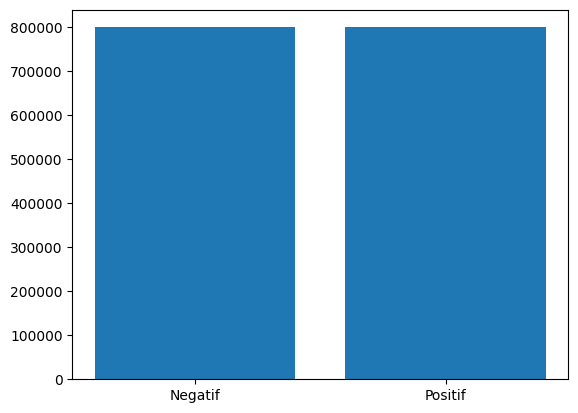

In [15]:
target_counts = df['target'].value_counts()
plt.bar(target_counts.index, target_counts.values)
plt.xticks(target_counts.index, ['Negatif', 'Positif'])
plt.show()

In [17]:
# Selection de donnee aleatoire pour reduire le nombre de donnee a traite
tweets_positifs = df[df['target'] == 1 ].sample(n=10000, random_state=40)
tweets_negatifs = df[df['target'] == 0 ].sample(n=10000, random_state=40)

df_select = pd.concat([tweets_positifs, tweets_negatifs])

df_select = df_select.reset_index(drop=True)
df_select

,target,ids,date,flag,user,text,target
0,1,2003914555,Tue Jun 02 07:21:44 PDT 2009,NO_QUERY,bgd1977,Ya me ha llegado Diary of the Dead,1.0
1,1,2190069608,Tue Jun 16 01:40:47 PDT 2009,NO_QUERY,nikkiwoods,@heykim - it's allll good. If I'm gonna get to...,1.0
2,1,1573631535,Tue Apr 21 02:05:34 PDT 2009,NO_QUERY,liverpoolchick,also wanna wish my friend well--she knows who ...,1.0
3,1,2000088245,Mon Jun 01 21:23:14 PDT 2009,NO_QUERY,jamers43,band concert went good time for bed soon. gon...,1.0
4,1,2001384797,Tue Jun 02 00:42:42 PDT 2009,NO_QUERY,steph_davies,"@jennifer_davies I'm not even annoyed. So, enj...",1.0
...,...,...,...,...,...,...,...
19995,0,1989712308,Mon Jun 01 02:32:24 PDT 2009,NO_QUERY,horse8978,@filit ill miss having fake fights with you,NaN
19996,0,1563751693,Mon Apr 20 00:06:24 PDT 2009,NO_QUERY,MrsHallows,"Well, finding it hard to sleep.",NaN
19997,0,2200345752,Tue Jun 16 18:46:19 PDT 2009,NO_QUERY,monicarvajal,I prefered jeans,NaN
19998,0,1985183328,Sun May 31 16:35:56 PDT 2009,NO_QUERY,Kinuur,Plants vs Zombies is way more addictive than P...,NaN


In [19]:
def genered_wordcloud(tweets, title):
    all_text = ' '.join(tweets)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.Figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()


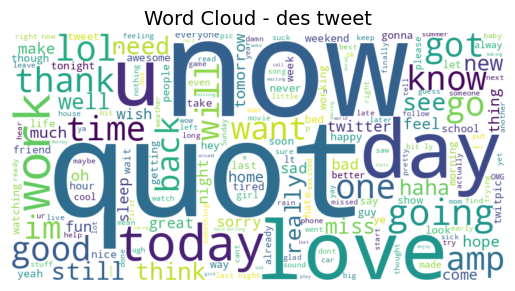

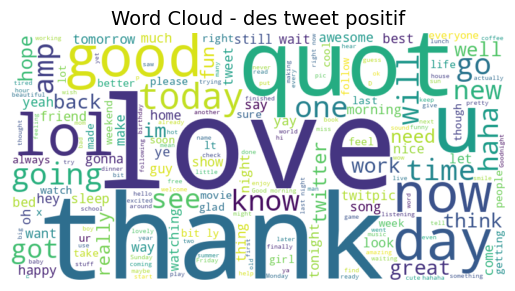

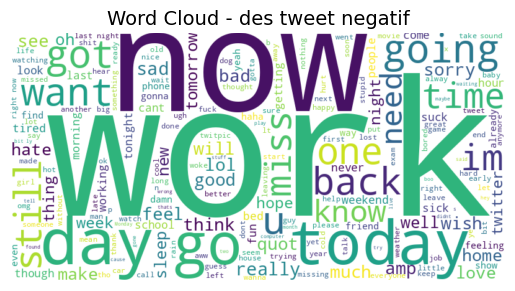

In [21]:
genered_wordcloud(df_select['text'], 'Word Cloud - des tweet')
genered_wordcloud(tweets_positifs['text'], 'Word Cloud - des tweet positif')
genered_wordcloud(tweets_negatifs['text'], 'Word Cloud - des tweet negatif')